<a href="https://colab.research.google.com/github/HermitCrab07/Impact_of_HbA1c_on_Readmission_Rates/blob/main/_7_DoWhy_Mediation_Diabetes130US_Hospitals_1999_2008_3_CAUSAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---

Moving on with our causal analysis to a second model to figure out if the measurement of HbA1c is a mediator. In other words, "Treatment" is Insurance. Every other effect is a mediator. The effect of Insurance on Readmission is through all the mediating variables.

---


In [ ]:
# Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore
# Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records
# BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014.
# Dataset was downloaded from UCI Machine Learning Repository.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/Analysis_Diabetes_Dataset_CausalInference/reanalysis_diabetes_dataset.csv')
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,Treatment,Insured,Readmission
count,7.151800e+04,7.151800e+04,71518.000000,71518.000000,71518.000000,71518.00000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000,71518.000000
mean,1.568156e+08,5.505160e+07,2.100254,3.593235,5.657457,4.28913,43.075478,1.430577,15.705025,0.280069,0.103540,0.177829,7.245700,0.215163,0.565941,0.398962
std,1.003769e+08,3.947573e+07,1.508301,5.269771,4.162580,2.94921,19.952338,1.759864,8.311163,1.068957,0.509187,0.603790,1.994674,0.410938,0.495636,0.489688
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.00000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,8.145807e+07,2.337577e+07,1.000000,1.000000,1.000000,2.00000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000
50%,1.440574e+08,4.816680e+07,1.000000,1.000000,7.000000,3.00000,44.000000,1.000000,14.000000,0.000000,0.000000,0.000000,8.000000,0.000000,1.000000,0.000000
75%,2.155513e+08,8.752222e+07,3.000000,3.000000,7.000000,6.00000,57.000000,2.000000,20.000000,0.000000,0.000000,0.000000,9.000000,0.000000,1.000000,1.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.00000,132.000000,6.000000,81.000000,42.000000,42.000000,12.000000,16.000000,1.000000,1.000000,1.000000


In [ ]:
!pip install dowhy==0.8
import dowhy
from dowhy import CausalModel

import pandas as pd
import numpy as np



---

Using DoWhy to estimate the Causal Effect: First define the Causal Graph using the variables that are in the dataset -

*   Treatment
*   Insured (Yes/N0)
*   Number of Medications
*   Number of Procedures
*   Number of Emergency Procedures

---



In [ ]:
!apt-get install graphviz libgraphviz-dev pkg-config
!pip install --force-reinstall pygraphviz

In [ ]:
import pygraphviz

Will use pygraphviz to explicitly define the relationships between the variables:

Building this causal model using a graph helps clarify the relationships between variables, thus making the assumptions easier to understand. This model states that Insurance is critical but it is affecting Readmission Rates through all the other procedures that occur in a hospital setting or even the medications a person is prescribed to take while he is home.




In [ ]:
# What if Insured affects the measurement of HbA1c which affects Readmission?
causal_graph = """digraph {
Treatment[label="Measurement of Hb1Ac"];
Insured[label="Insured"];
num_medications[label="Number of Medications"];
num_procedures[label="Number of Procedures"];
num_lab_procedures[label="Number of Lab Procedures"];
number_emergency[label="Number of Emergency Procedures"];
Readmission[label="Readmission"];
Treatment -> Readmission;
Insured -> Treatment;
Insured -> num_medications;
Insured -> num_procedures;
Insured -> num_lab_procedures;
Insured -> number_emergency;
num_medications -> Readmission;
num_lab_procedures -> Readmission;
num_procedures -> Readmission;
number_emergency -> Readmission;
}"""

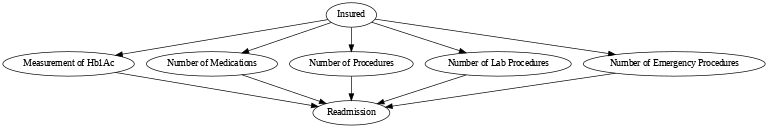

In [ ]:
model = dowhy.CausalModel(
    data=df,
    graph=causal_graph,
    treatment=["Insured"],
    # mediator=["Number of Medications", "Number of Procedures", "Number of Emergency Procedures", "Treatment"],
    # mediator=["num_medications", "num_procedures", "num_lab_procedures", "number_emergency", "Treatment"],
    outcome= ["Readmission"],
)

model.view_model()

from IPython.display import Image, display
# Display the image (without forcing dimensions)
display(Image(filename="causal_model.png", width=800, height=200))

In [ ]:
# Identify the causal effect
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

# Natural direct effect (nde)
identified_estimand_nde = model.identify_effect(estimand_type="nonparametric-nde",
                                            proceed_when_unidentifiable=True)
print(identified_estimand_nde)

Estimand type: nonparametric-ate

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                     
──────────(E[Readmission])
d[Insured]                
Estimand assumption 1, Unconfoundedness: If U→{Insured} and U→Readmission then P(Readmission|Insured,,U) = P(Readmission|Insured,)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

Estimand type: nonparametric-nde

### Estimand : 1
Estimand name: mediation
Estimand expression:
 ⎡    d                                 ⎤
E⎢──────────(Readmission|num_procedures)⎥
 ⎣d[Insured]                            ⎦
Estimand assumption 1, Mediation: num_procedures intercepts (blocks) all directed paths from Insured to R,e,a,d,m,i,s,s,i,o,n except the path {Insured}→{R,e,a,d,m,i,s,s,i,o,n}.
Estimand assumption 2, First-stage-unconfoundedness: If U→{Insured} and U→{num_procedures} then P(num_procedures|Insured,U) = P(num_procedures|Insured)
Estima

In [ ]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Specify first and second stage models using dowhy's defaults
estimate = model.estimate_effect(identified_estimand_nde, method_name="mediation.two_stage_regression",
                                 method_params={"mediator_columns": ["num_medications", "num_procedures", "num_lab_procedures", "number_emergency", "Treatment"]})
print(estimate.value) # Print the estimated causal effect value


two_stage_regression
{'control_value': 0, 'treatment_value': 1, 'test_significance': None, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': [], 'first_stage_model': None, 'second_stage_model': None, 'mediator_columns': ['num_medications', 'num_procedures', 'num_lab_procedures', 'number_emergency', 'Treatment']}
{'control_value': 0, 'treatment_value': 1, 'test_significance': None, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': [], 'first_stage_model': None, 'second_stage_model': None, 'mediator_columns': ['num_medications', 'num_procedures', 'num_lab_procedures', 'number_emergency', 'Treatment']}
{'control_value': 0, 'treatment_value': 1, 'test_significance': None, 'evaluate_effect_strength': False, 'confidence_intervals': False, 'target_units': 'ate', 'effect_modifiers': [], 'first_stage_model': None, 'second_stage_model': None, 'mediator_columns': ['num_medications

Interpretation of the Estimate:

We wanted to figure out the effect of Insurance on Readmission, while considering the mediating effects of other variables (for example, number of medications, procedures, the lab procedures, emergency procedures, and HbA1c measurement).

An estimate of -0.04 suggests that being Insured has a negative causal effect on Readmission, independent of the mediating variables.

In other words, even after accounting for the  effects of insurance through these mediators, being insured has an extra effect, i.e., it is associated with a reduction in Readmission rates.

Specifically, an estimate of -0.04 indicates that, on average, being insured is associated with a 4 percentage point decrease in the probability of hospital readmission.
